# Монте-Карло 

Статья: https://github.com/avito-tech/applied_statistics/blob/main/Monte-Carlo.ipynb

**В чем суть метода Монте-Карло?**      
В генерации большого количества экспериментов и подсчета каких-то статистик на нем

Перед проведением эксперимента нам важно проверить наш критерий 
1. Берем искуственные распределения и делаем АА тест, считаем Type I. Хотим, чтобы доверительный интервал для Type I включал в себя наш выбранный уровень значимости alpha 
2. Тестируем разные sample_size и смотрим, начиная с какого размера выборки критерий начинает выдавать правильный type I. Так мы поймем минимальный sample_size

**Вместе искуственных распределений лучше брать исторические данные в компании** 

Допустим, у нас 10 категорий, в каждой категории 10 городов, и еще у нас 12 месяцев     
Тогда получим 10 * 10 * 12 = 1200 датасетов!    
Этого обычно достаточно, чтобы провалилидировать критерий

**Как понять, какой критерий лучше?**

Сэмплируем много раз распределения и делаем AB тест (одно распределение с измененным на MDE средним). Важно имитировать эффект, который будет близко к настоящему

Считаем мощность и берем критерий, у которого она выше

In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import random

plt.rcParams['figure.dpi'] = 150

Основная идея: сначала посмотреть, какая реальная Type I 

Если она меньше заданного alpha, то наш критерий "осторожен". Он расширяет область принятия нулевой гипотезы. Поэтому и Type II будет больше, то есть у такого критерия меньшая мощность 

А вот есть реальная Type I выше alpha, таким критерием лучше не пользоваться

In [ ]:
# Делаем АА тест и считаем Type I

np.random.seed(42)

bad_cnt = 0
N = 10000
alpha=0.05

sample_dist = stats.norm(loc=2, scale=3)
mu0=sample_dist.expect()
for i in range(N):
    # Генерирую выборку теста и контроля
    test    = sample_dist.rvs(5)
    control = sample_dist.rvs(5)

    # Запускаю критерий и считаю p-value
    pvalue = stats.ttest_ind(test, control, alternative='two-sided').pvalue
    
    # Проверяю, что pvalue < alpha
    bad_cnt += (pvalue < alpha)


print(f"FPR: {round(bad_cnt / N, 4)}")

FPR: 0.0519


In [ ]:
# Лучше еще посчитать доверительный интервал, 
# чтобы понять, лежит ли в нем наше alpha

from statsmodels.stats.proportion import proportion_confint

proportion_confint(count = bad_cnt, nobs = N, alpha=0.05, method='wilson')

(0.04772180742973847, 0.05642233191006188)

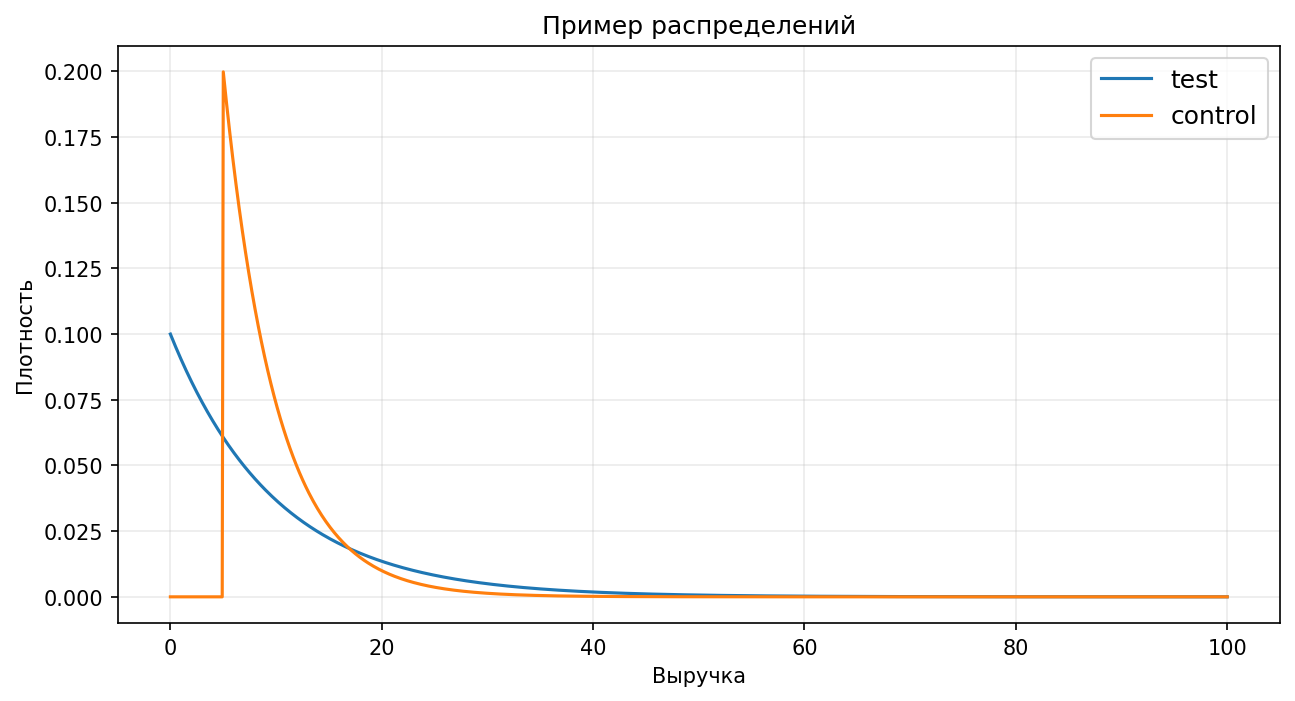

In [19]:
test_dist = stats.expon(scale = 10)
control_dist = stats.expon(loc=5, scale = 5)

x = np.linspace(0, 100, 1000)

plt.figure(figsize=(10, 5))
plt.title('Пример распределений', fontsize=12)
plt.plot(x, test_dist.pdf(x), label='test')
plt.plot(x, control_dist.pdf(x), label='control')
plt.xlabel('Выручка')
plt.ylabel('Плотность')

plt.legend(fontsize=12)
plt.grid(linewidth=0.2)
plt.show()

In [22]:
# Сделаем функцию для проверки критерия при AA тесте

def check_criterion_aa(test_distribution, control_distribution, sample_size, n_iter=10000):
    alpha=0.05

    np.random.seed(35)

    bad_cnt = 0
    for _ in range(n_iter):
        # Generate samples
        test = test_distribution.rvs(sample_size)
        control = control_distribution.rvs(sample_size)

        pvalue = stats.ttest_ind(test, control, equal_var=False, alternative='two-sided').pvalue

        if pvalue <= alpha:
            bad_cnt += 1
    
    type_one = bad_cnt / n_iter

    ci_left, ci_right = proportion_confint(count=bad_cnt, nobs=n_iter, alpha=0.05, method='wilson')

    print(f"Type I: {type_one:.3f}")
    print(f"CI: [{ci_left:.3f}, {ci_right:.3f}]")


test_distribution = stats.expon(scale=10)
control_distribution = stats.expon(loc=5, scale=5)
sample_size=20

check_criterion_aa(test_distribution=test_distribution, 
                   control_distribution=control_distribution, 
                   sample_size=sample_size)

Type I: 0.060
CI: [0.056, 0.065]


Критерий невалидный, так как alpha лежит левее двоерительного интервала. То есть критерий ошибается больше, чем мы задаем

In [28]:
 # Находим отимальный размер выборки, чтобы критерий был валидный 
 # (уровень значимости 0.05 лежит в доверительном интервале)

for n_sample in np.arange(20, 110, 20):
    print(f"Sample size = {n_sample}")
    check_criterion_aa(test_distribution=test_distribution, 
                   control_distribution=control_distribution, 
                   sample_size=n_sample)
    print("---")

Sample size = 20
Type I: 0.060
CI: [0.056, 0.065]
---
Sample size = 40
Type I: 0.061
CI: [0.057, 0.066]
---
Sample size = 60
Type I: 0.053
CI: [0.048, 0.057]
---
Sample size = 80
Type I: 0.054
CI: [0.049, 0.058]
---
Sample size = 100
Type I: 0.053
CI: [0.049, 0.058]
---


Получили, что начиная с 60 наблюдений критерий валидный 

In [ ]:
# Смотрим на другой критерий. 
# Здесь мало наблюдений и ЦПТ неверна 
# Но при этом ttest дается низкую type I, то есть критерий использовать можно
# Он будет менее мощный

test_dist = stats.expon(scale=20)
control_dist = stats.expon(scale=20)

check_criterion_aa(test_distribution=test_dist, control_distribution=control_dist, sample_size=10)

Type I: 0.040
CI: [0.036, 0.044]


In [ ]:
# Чтобы из двух критериев выбрать лучший, просто смотрим, 
# у какого из них выше мощность 
# Для этого делаем много AB тестов 

alpha = 0.05
beta = 0.2

good_cnt = 0
n_iter = 10000

# Смотрим на Normal Distribution 

sample_size = 15
sample_distribution = stats.norm(loc=2, scale=3)
var = 3

# Caculate MDE
mde = (stats.norm().ppf(1 - alpha) + stats.norm().ppf(1 - beta)) * np.sqrt(var / sample_size)

for _ in range(n_iter):
    control = sample_distribution.rvs(sample_size)
    test = sample_distribution.rvs(sample_size) + mde

    pvalue = stats.ttest_ind(test, control, equal_var=False, alternative='two-sided').pvalue

    if pvalue >= alpha:
        good_cnt += 1

power = good_cnt / n_iter
print(f"Power: {power:.3f}")

Power: 0.836


In [44]:
# Смотрим на Exponential Distribution
# Тут мощность поменьше

good_cnt = 0

sample_distribution = stats.expon(scale=0.5)

for _ in range(n_iter):
    control = sample_distribution.rvs(sample_size)
    test = stats.expon(scale=0.25).rvs(sample_size)

    pvalue = stats.ttest_ind(test, control, equal_var=False, alternative='two-sided').pvalue

    if pvalue >= alpha:
        good_cnt += 1

power = good_cnt / n_iter
print(f"Power: {power:.3f}")

Power: 0.633


In [77]:
# Просто сделаем AB тест

alpha = 0.05
beta = 0.2

sample_size = 100

# Caculate MDE
mde = (stats.norm().ppf(1 - alpha) + stats.norm().ppf(1 - beta)) * np.sqrt(250 / sample_size)

print(f"MDE = {mde:.1f}")

control = stats.norm(loc=1000, scale=250).rvs(sample_size)
test = stats.norm(loc=1060, scale=250).rvs(sample_size)

obj = stats.ttest_ind(test, control, equal_var=False, alternative='two-sided')

statistic, pvalue = obj
ci_left, ci_right = obj.confidence_interval(confidence_level=0.05)

print(f"Значение T статистики: {statistic:.1f}")
print(f"pvalue = {pvalue:.3f}")
print(f"CI = [{ci_left:.1f}, {ci_right:.1f}]")

MDE = 3.9
Значение T статистики: 2.3
pvalue = 0.025
CI = [73.1, 77.3]


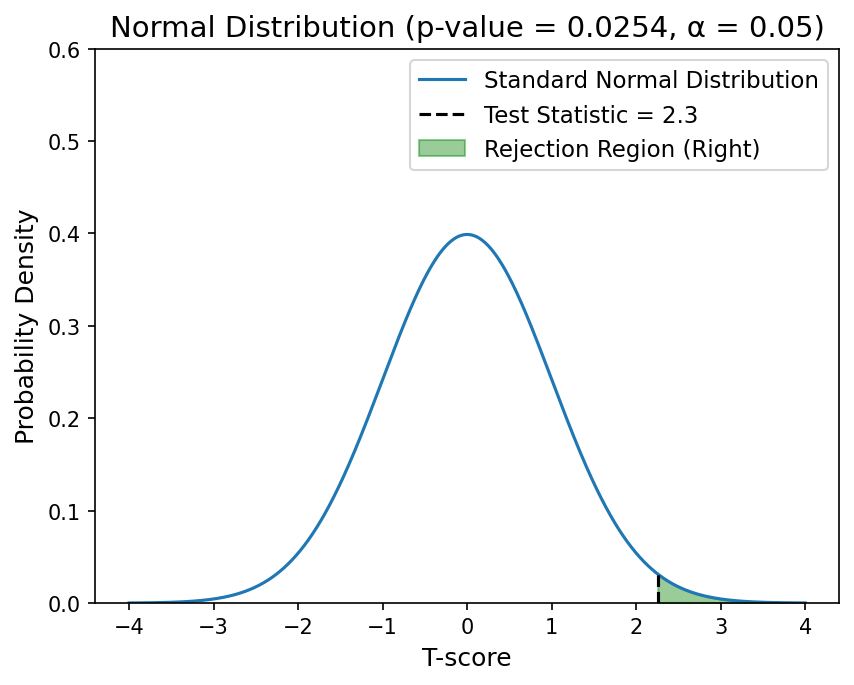

In [78]:
# Visualization

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.plot(x, y, label='Standard Normal Distribution')
plt.plot([statistic, statistic], [0, stats.norm().pdf(statistic)], color='black', linestyle='--', label=f'Test Statistic = {statistic:.1f}')

# Fill areas only if p-value < alpha
if pvalue < alpha:
    if statistic < 0:
        # Red fill on the left
        x_fill = x[x <= statistic]
        plt.fill_between(x_fill, stats.norm.pdf(x_fill), alpha=0.4, color='red', label='Rejection Region (Left)')
    else:
        # Green fill on the right
        x_fill = x[x >= statistic]
        plt.fill_between(x_fill, stats.norm.pdf(x_fill), alpha=0.4, color='green', label='Rejection Region (Right)')

plt.ylim(0, 0.6)
plt.xlabel('T-score', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title(f'Normal Distribution (p-value = {pvalue:.4f}, α = {alpha})', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.show()

## Exponential Distribution Formulas

**Probability Density Function (PDF):**
$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**Cumulative Distribution Function (CDF):**
$$F(x) = 1 - e^{-\lambda x}$$

**Mean:**
$$\mu = E[X] = \frac{1}{\lambda}$$

**Variance:**
$$\sigma^2 = \text{Var}(X) = \frac{1}{\lambda^2}$$


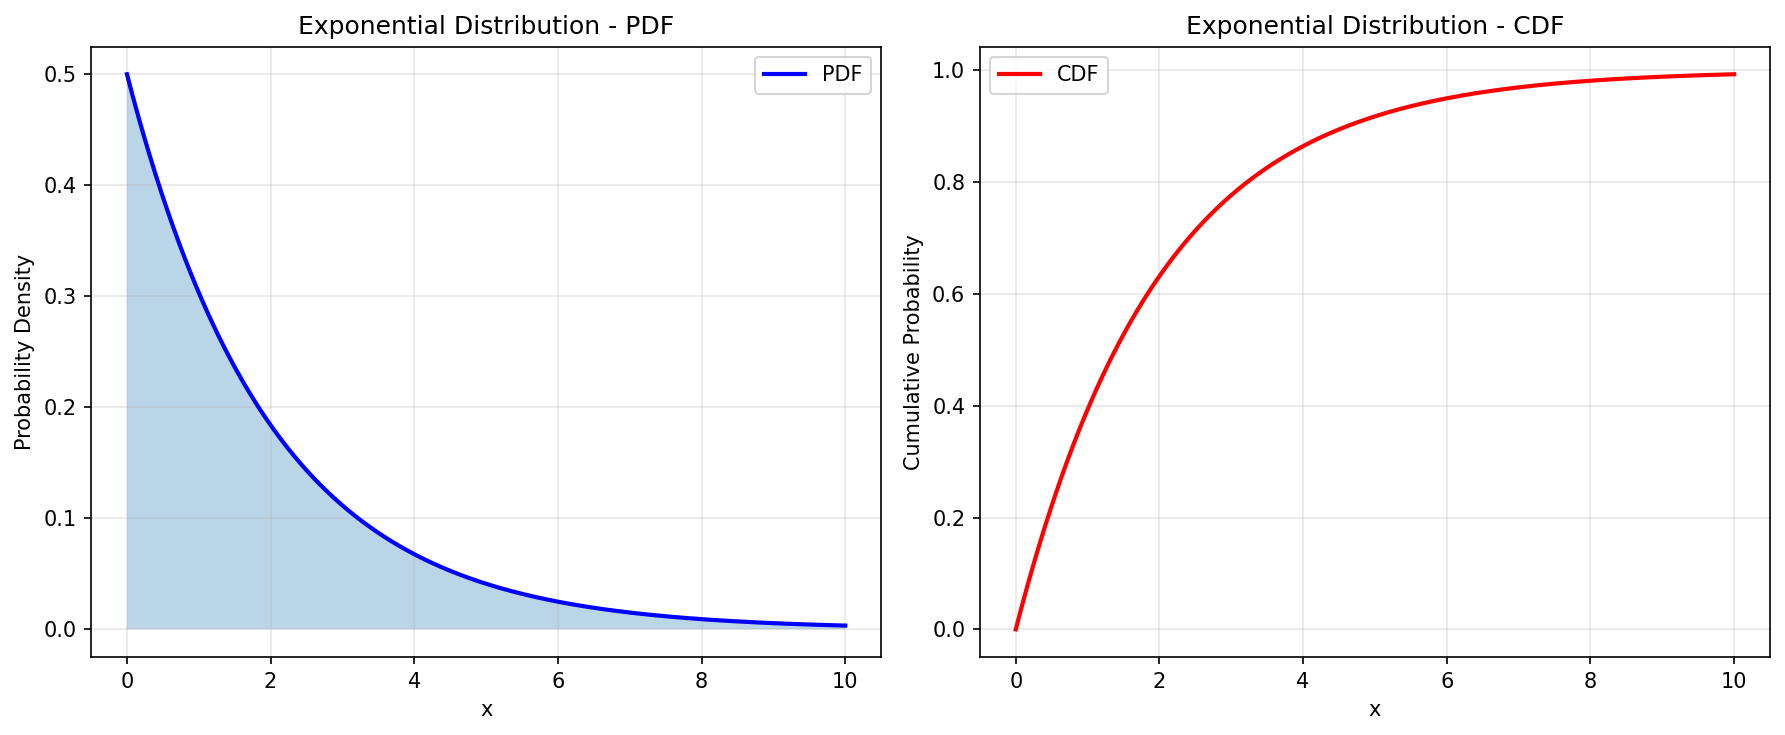

In [16]:
# Create exponential distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Parameters
lambda_param = 0.5
x = np.linspace(0, 10, 1000)

# PDF
pdf = stats.expon(scale=1/lambda_param).pdf(x)
axes[0].plot(x, pdf, 'b-', linewidth=2, label='PDF')
axes[0].fill_between(x, pdf, alpha=0.3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Exponential Distribution - PDF')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# CDF
cdf = stats.expon(scale=1/lambda_param).cdf(x)
axes[1].plot(x, cdf, 'r-', linewidth=2, label='CDF')
axes[1].set_xlabel('x')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Exponential Distribution - CDF')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()